<a href="https://colab.research.google.com/github/Tselovanska/machine-learning-course/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/content/drive/MyDrive/Colab Notebooks')

from process_bank_churn import preprocess_data,preprocess_new_data

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

train_df = pd.read_csv(folder_path + 'train.csv')
result = preprocess_data(train_df)

X_train = result['X_train']
train_targets = result['train_targets']
X_val = result['X_val']
val_targets = result['val_targets']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [3]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)




KNeighborsClassifier()

In [4]:
roc_auc_score(train_targets, knn.predict_proba(X_train)[:,1])

np.float64(0.9559428457733543)

In [5]:
roc_auc_score(val_targets, knn.predict_proba(X_val)[:,1])

np.float64(0.852585568283147)

відбулось перенавчання моделі

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [6]:
knn_new = KNeighborsClassifier()
params_knn_new = {'n_neighbors': np.arange(1,25)}
knn_new_gs = GridSearchCV(knn_new, params_knn_new, cv=5, scoring='roc_auc')
knn_new_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

In [7]:
knn_new_best = knn_new_gs.best_estimator_
print(knn_new_gs.best_params_, knn_new_gs.best_score_)

{'n_neighbors': np.int64(19)} 0.8853000771869176


In [8]:
roc_auc_score(train_targets, knn_new_best.predict_proba(X_train)[:,1])

np.float64(0.9227310044165035)

In [9]:
roc_auc_score(val_targets, knn_new_best.predict_proba(X_val)[:,1])

np.float64(0.8908141847863366)

Розрив між тренувальними даними та валідаційними знизився - з 0.95-0.85 до 0.92-0.89, що вказує про наближення значень.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [10]:
dt = DecisionTreeClassifier(random_state=42)

params_dt = {
    'max_depth': np.arange(1, 20, 2),
    'max_leaf_nodes': np.arange(2, 10, 1)
}

start = time.time()
dt_gs = GridSearchCV(dt, params_dt, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)
elapsed = time.time() - start

print(f'Час пошуку: {elapsed:.2f} сек')
print(f'Найкращі параметри: {dt_gs.best_params_}')

dt_best = dt_gs.best_estimator_

train_auroc = roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])
val_auroc = roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1])

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {val_auroc:.4f}')
print(f'Difference: {train_auroc - val_auroc:.4f}')

Час пошуку: 6.11 сек
Найкращі параметри: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(9)}
Train AUROC: 0.9001
Val AUROC: 0.8984
Difference: 0.0017


Хоч ця модель і показує гірше значення на тренувальних даних, але вона покращує результат на валдіаційних даних, а також - різниця між тренувальними та валідаційними показниками стала значно нижча.


4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [11]:
dt_for_rs = DecisionTreeClassifier(random_state=42)
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

start = time.time()
dt_rs = RandomizedSearchCV(dt_for_rs, params_dt, n_iter=40, cv=3, scoring='roc_auc', random_state=42)
dt_rs.fit(X_train, train_targets)
elapsed = time.time() - start

print(f'Час пошуку: {elapsed:.2f} сек')
print(f'Найкращі параметри: {dt_rs.best_params_}')

dt_random_search_best = dt_rs.best_estimator_

train_auroc = roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1])
val_auroc = roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:, 1])

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {val_auroc:.4f}')
print(f'Difference: {train_auroc - val_auroc:.4f}')

Час пошуку: 1.51 сек
Найкращі параметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Train AUROC: 0.9169
Val AUROC: 0.9166
Difference: 0.0003


In [12]:
# порівняння
comparison = pd.DataFrame({
    'GridSearch (dt_best)': dt_best.get_params(),
    'RandomSearch (dt_random_search_best)': dt_random_search_best.get_params()
})
print(comparison.loc[['criterion', 'splitter', 'max_depth', 'max_leaf_nodes',
                       'min_samples_split', 'min_samples_leaf', 'max_features']])

                  GridSearch (dt_best) RandomSearch (dt_random_search_best)
criterion                         gini                              entropy
splitter                          best                                 best
max_depth                            5                                   16
max_leaf_nodes                       9                                   14
min_samples_split                    2                                   20
min_samples_leaf                     1                                    2
max_features                      None                                 None


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [13]:
test_data = pd.read_csv('test.csv')

X_test = preprocess_new_data(
    test_data,
    result['input_cols'],
    result['numeric_cols'],
    result['categorical_cols'],
    result['scaler'],
    result['encoder']
)

test_probs = dt_random_search_best.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': test_data['id'],
    'Exited': test_probs
})

submission.to_csv('submission.csv', index=False)

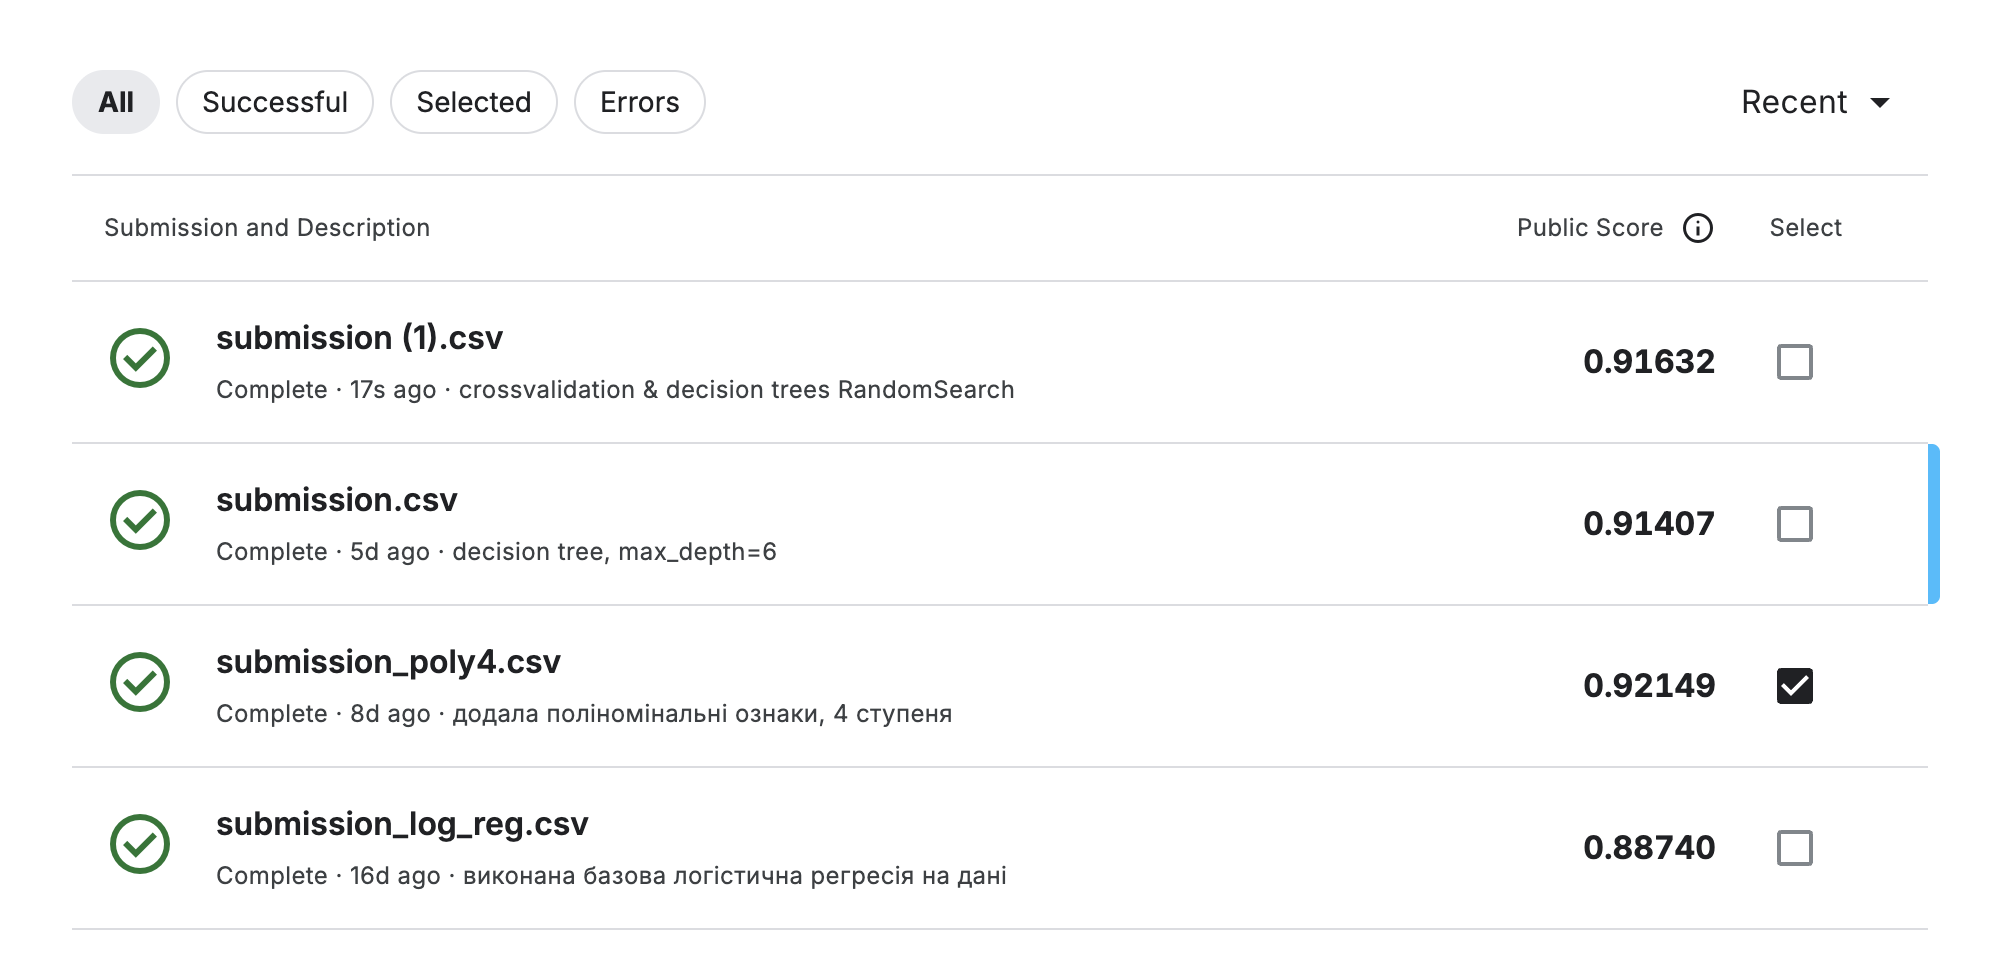